# Exploratory Data Analysis (EDA)
## AI vs Human Text Detection

Bu notebook'ta veri setini inceliyoruz:
- Veri yapısı
- Sınıf dağılımı (Class Distribution)
- Metin uzunluk analizi (Text Length Analysis)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

os.makedirs("../results/figures", exist_ok=True)

df = pd.read_csv("../data/AI_Human.csv")
print(df.head())
print(df.info())

# Hocanin istedigi ornek metinler (Example texts)
print("\n--- Human Text Example ---")
print(df[df['generated'] == 0.0]['text'].iloc[0][:500] + "...")
print("\n--- AI Text Example ---")
print(df[df['generated'] == 1.0]['text'].iloc[0][:500] + "...")

                                                text  generated
0  Cars. Cars have been around since they became ...        0.0
1  Transportation is a large necessity in most co...        0.0
2  "America's love affair with it's vehicles seem...        0.0
3  How often do you ride in a car? Do you drive a...        0.0
4  Cars are a wonderful thing. They are perhaps o...        0.0
<class 'pandas.DataFrame'>
RangeIndex: 487235 entries, 0 to 487234
Data columns (total 2 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   text       487235 non-null  str    
 1   generated  487235 non-null  float64
dtypes: float64(1), str(1)
memory usage: 7.4 MB
None

--- Human Text Example ---
Cars. Cars have been around since they became famous in the 1900s, when Henry Ford created and built the first ModelT. Cars have played a major role in our every day lives since then. But now, people are starting to question if limiting car usage would be a good thing. To

## 1. Class Distribution (Sınıf Dağılımı)

generated
0.0    305797
1.0    181438
Name: count, dtype: int64

0 = Human, 1 = AI


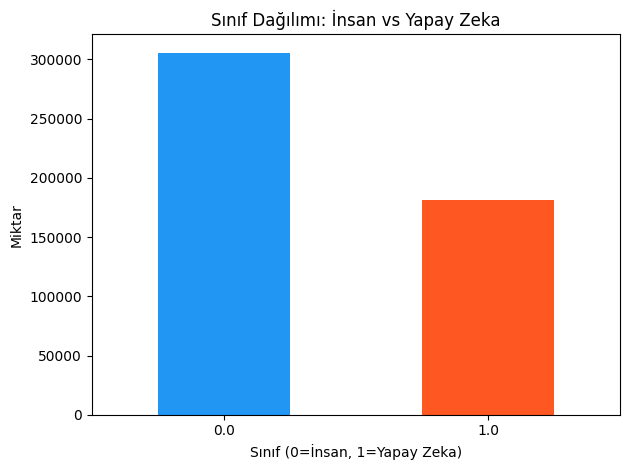

In [2]:
print(df['generated'].value_counts())
print()
print("0 = Human, 1 = AI")

ax = df['generated'].value_counts().plot(kind='bar', color=['#2196F3', '#FF5722'])
plt.title('Sınıf Dağılımı: İnsan vs Yapay Zeka')
plt.xlabel('Sınıf (0=İnsan, 1=Yapay Zeka)')
plt.ylabel('Miktar')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../results/figures/class_distribution.png', dpi=150)
plt.show()

## 2. Text Length Analysis (Metin Uzunluk Analizi)

Metin uzunluk istatistikleri:
count    487235.000000
mean       2269.586592
std         988.814028
min           1.000000
25%        1583.000000
50%        2102.000000
75%        2724.000000
max       18322.000000
Name: length, dtype: float64


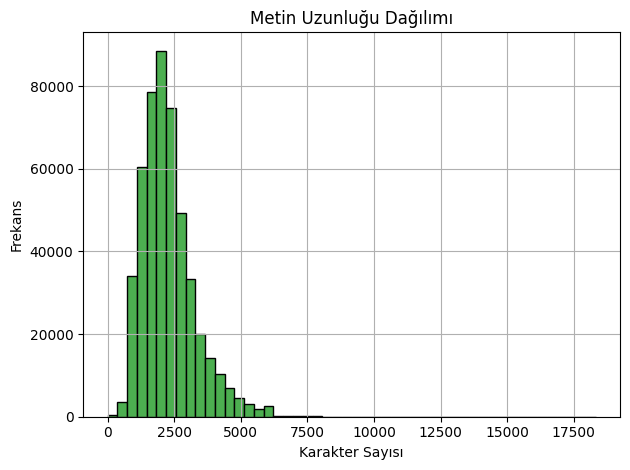

In [3]:
df['length'] = df['text'].apply(len)

print("Metin uzunluk istatistikleri:")
print(df['length'].describe())

df['length'].hist(bins=50, color='#4CAF50', edgecolor='black')
plt.title('Metin Uzunluğu Dağılımı')
plt.xlabel('Karakter Sayısı')
plt.ylabel('Frekans')
plt.tight_layout()
plt.savefig('../results/figures/text_length_distribution.png', dpi=150)
plt.show()

## 3. Sınıfa Göre Metin Uzunluğu Karşılaştırması

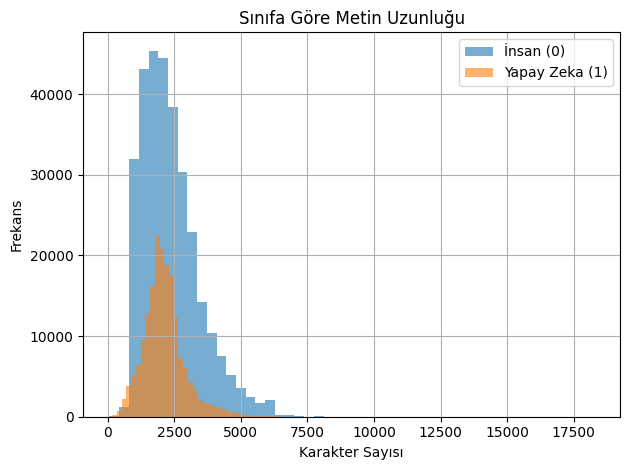

In [4]:
df.groupby('generated')['length'].hist(bins=50, alpha=0.6, legend=True)
plt.title('Sınıfa Göre Metin Uzunluğu')
plt.xlabel('Karakter Sayısı')
plt.ylabel('Frekans')
plt.legend(['İnsan (0)', 'Yapay Zeka (1)'])
plt.tight_layout()
plt.savefig('../results/figures/text_length_by_class.png', dpi=150)
plt.show()